In [36]:
# Import all required modules
# Disable warnings
import warnings

import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize

warnings.filterwarnings("ignore")

# Import plotting modules and set up
import seaborn as sns

sns.set()
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [37]:
sns.set_context("notebook", font_scale=1.5, rc={"figure.figsize": (11,8), "axes.titlesize": 18})

from matplotlib import rcParams
rcParams["figure.figsize"] = 11,8

In [38]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [39]:
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


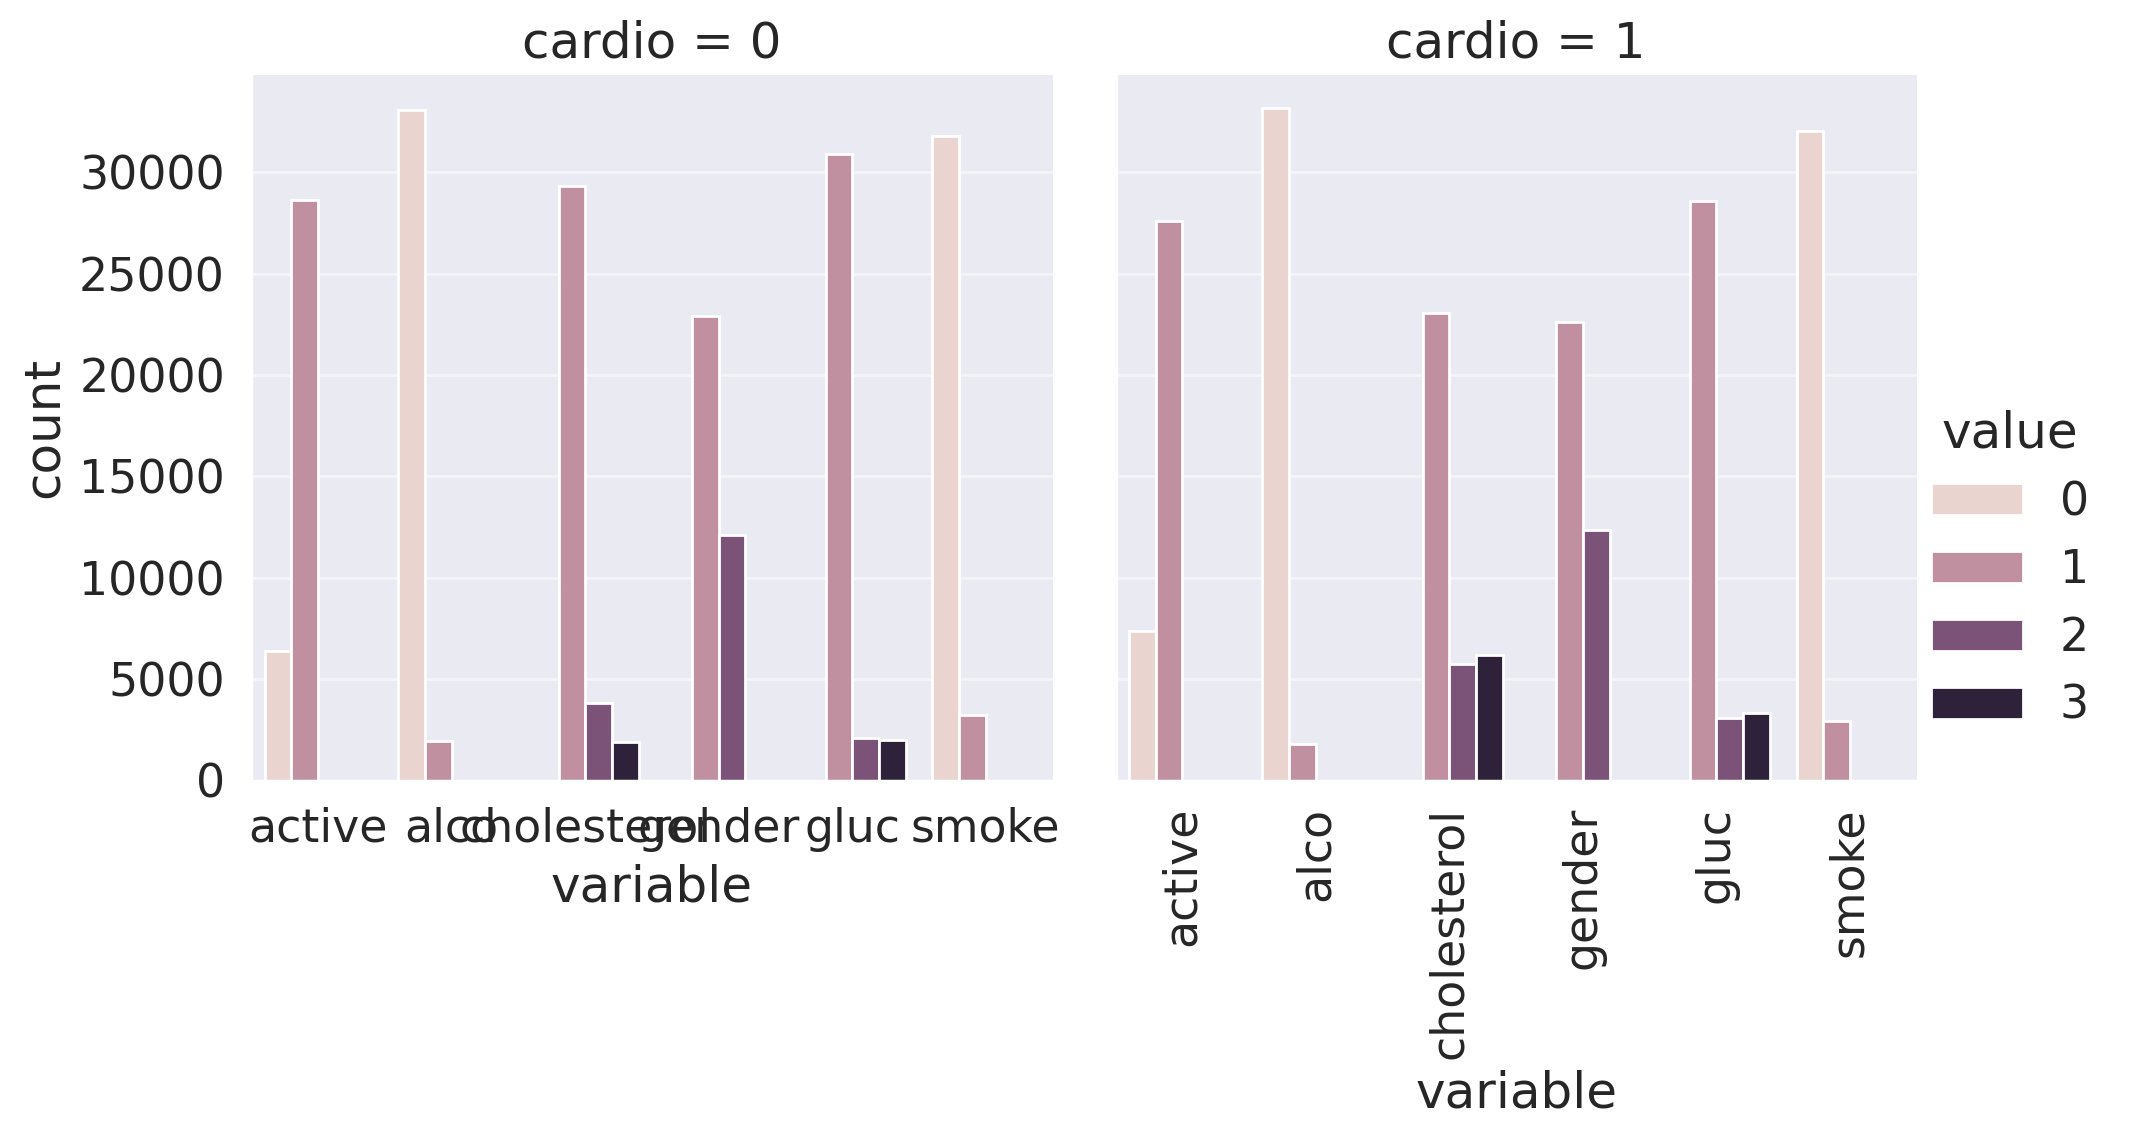

In [40]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"],
)
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    data=df_uniques,
    x="variable",
    y="count",
    hue="value",
    kind="bar",
    col = "cardio",
)
plt.xticks(rotation='vertical');

In [41]:
for c in df.columns:
    n = df[c].nunique()
    print(c)
    if n <= 3:
        print(n, sorted(df[c].value_counts().to_dict().items()))
    else:
        print(n)
    print(10 * "-")

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
----------
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
----------
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
----------
smoke
2 [(0, 63831), (1, 6169)]
----------
alco
2 [(0, 66236), (1, 3764)]
----------
active
2 [(0, 13739), (1, 56261)]
----------
cardio
2 [(0, 35021), (1, 34979)]
----------


In [42]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [43]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [44]:
df["gender"].value_counts()

gender
1    45530
2    24470
Name: count, dtype: int64

In [45]:
df[(df["alco"]==1) & (df["gender"]==1)].shape[0]

1161

In [46]:
df[(df["alco"]==1) & (df["gender"]==2)].shape[0]

2603

In [47]:
(df[(df["gender"]==1) & (df["smoke"]==1)].shape[0]) / (df[df["gender"]==1].shape[0]) * 100

1.7856358444981333

In [48]:
(df[(df["gender"]==2) & (df["smoke"]==1)].shape[0]) / (df[df["gender"]==2].shape[0]) * 100

21.88802615447487

In [70]:
print(round(df[df["smoke"]==1]["age"].median() / 365))
print(round((df[df["smoke"]==1]["age"].median() % 365) / 30))

52
5


In [71]:
print(round(df[df["smoke"]==0]["age"].median() / 365))
print(round((df[df["smoke"]==0]["age"].median() % 365) / 30))

54
0


In [51]:
df["age_years"] = (df["age"]/365).astype(int)

In [53]:
df["age_months"] = ((df["age"] % 365)/30).astype(int)

In [72]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'age_months'],
      dtype='str')

In [76]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_months
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,4
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,5
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,8
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,3
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,8
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,11
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,2
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,5


In [77]:
smoking_old_men = df[
    (df["gender"] == 2)
    & (df["age_years"] >= 60)
    & (df["age_years"] < 65)
    & (df["smoke"] == 1)
]

In [78]:
smoking_old_men[
    (smoking_old_men["cholesterol"] == 1) & (smoking_old_men["ap_hi"] < 120)
]["cardio"].mean()

np.float64(0.2777777777777778)

In [79]:
smoking_old_men[
    (smoking_old_men["cholesterol"] == 3)
    & (smoking_old_men["ap_hi"] >= 160)
    & (smoking_old_men["ap_hi"] < 180)
]["cardio"].mean()

np.float64(0.9333333333333333)

In [80]:
df["BMI"] = df["weight"] / (df["height"] / 100) ** 2

In [81]:
df[df["gender"]==1]["BMI"].mean()

np.float64(27.98758344183285)

In [82]:
df[df["gender"]==2]["BMI"].mean()

np.float64(26.75444235728935)

In [83]:
df["BMI"].median()

np.float64(26.374068120774975)

In [130]:
df["age"].isna().sum()

np.int64(6222)

In [85]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'age_months', 'BMI'],
      dtype='str')

In [89]:
df_to_remove = df[
    (df["ap_lo"] > df["ap_hi"]) |
    (df["height"] < df["height"].quantile(0.025)) |
    (df["height"] > df["height"].quantile(0.975)) |
    (df["weight"] < df["weight"].quantile(0.025)) |
    (df["weight"] > df["weight"].quantile(0.975))
]

print((df_to_remove.shape[0] / df.shape[0]) * 100)

7.964285714285714


In [87]:
df = df[~df.isin(df_to_remove.index)]

<Axes: >

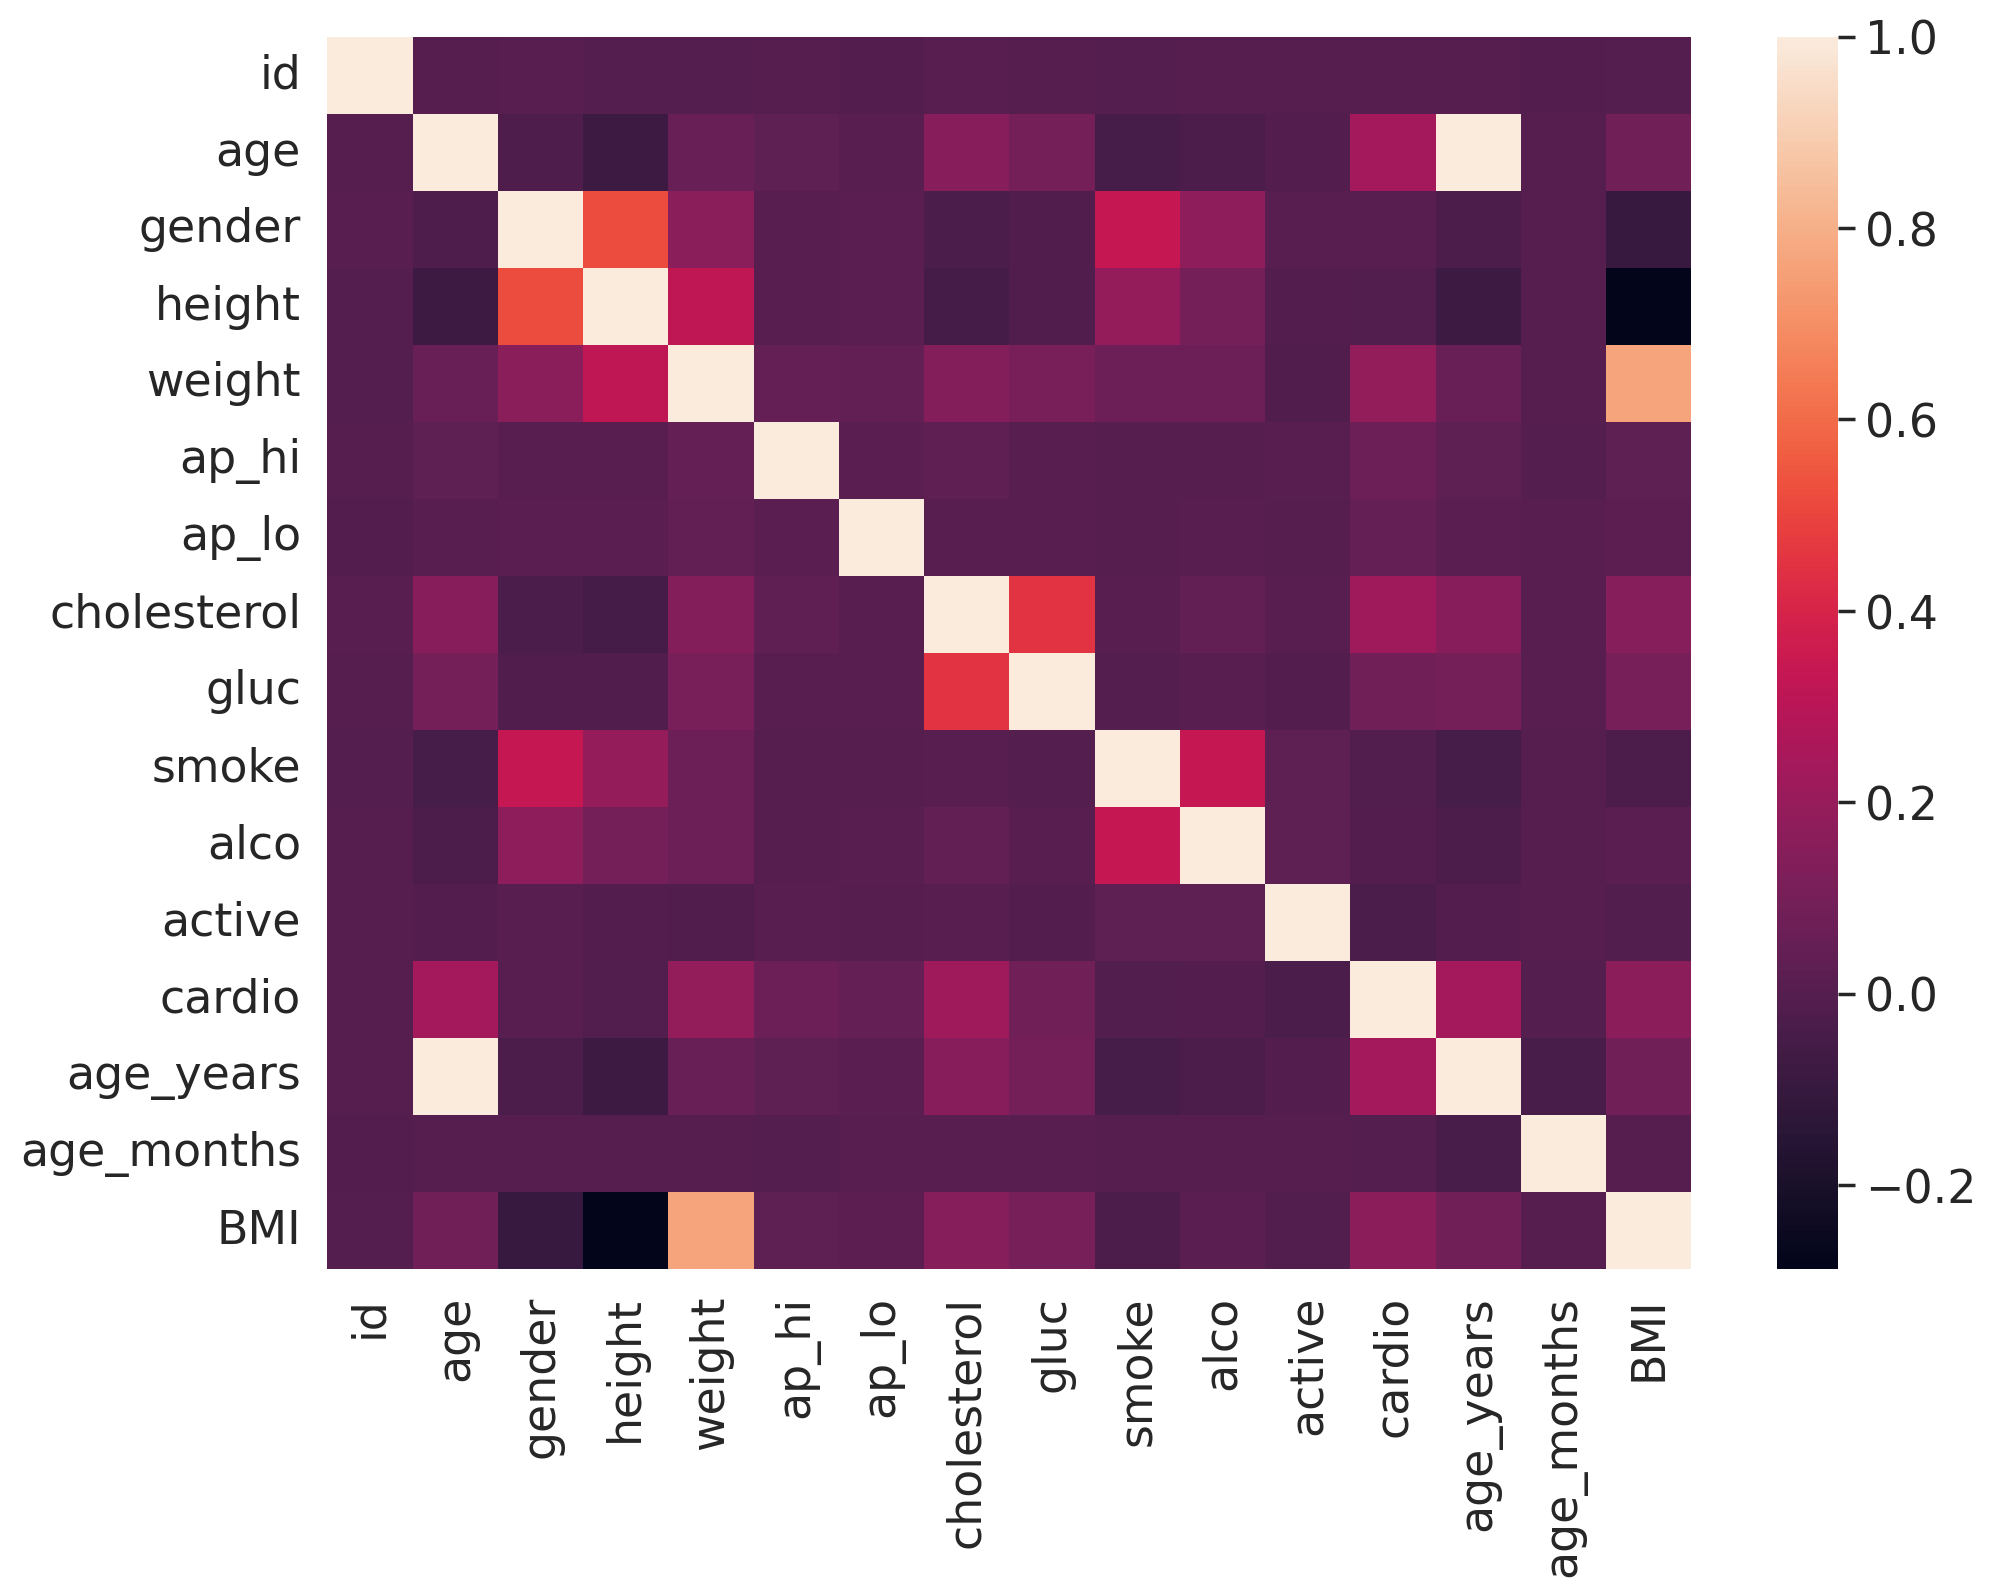

In [96]:
sns.heatmap(df.corr(method="pearson"))

In [102]:
df_violin = pd.melt(
    frame=df,
    value_vars = ["height"],
    id_vars = ["gender"]
)
print(df_violin)

       gender variable  value
0           2   height  168.0
1           1   height  156.0
2           1   height    NaN
3           2   height  169.0
4           1   height  156.0
...       ...      ...    ...
69995       2   height  168.0
69996       1   height  158.0
69997       2   height    NaN
69998       1   height  163.0
69999       1   height  170.0

[70000 rows x 3 columns]


<Axes: xlabel='variable', ylabel='value'>

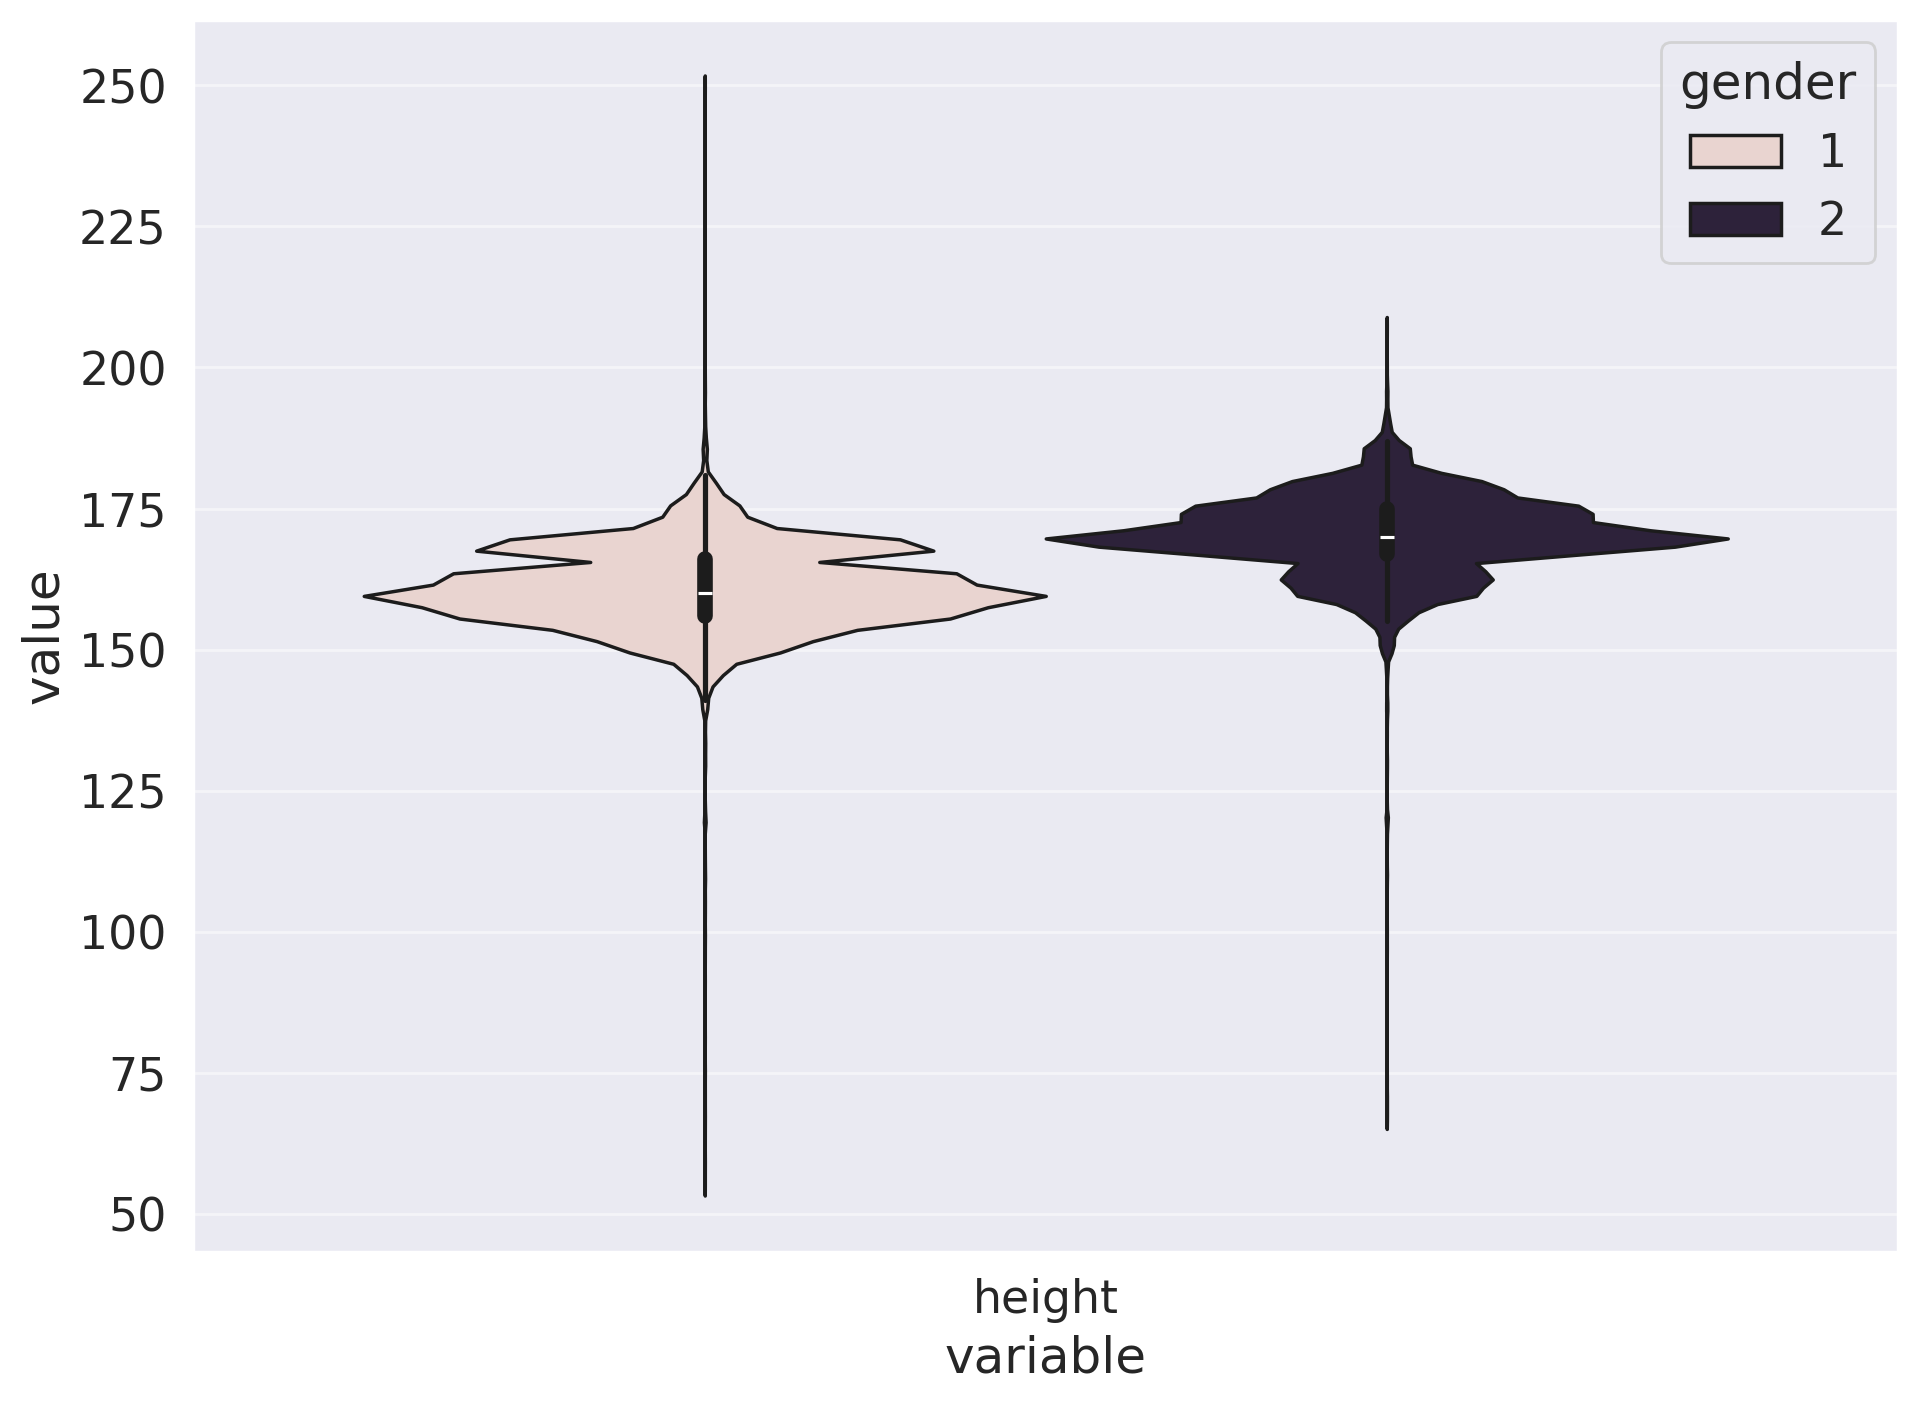

In [104]:
sns.violinplot(data=df_violin, x = "variable", hue = "gender", y = "value", scale = "count")

<Axes: >

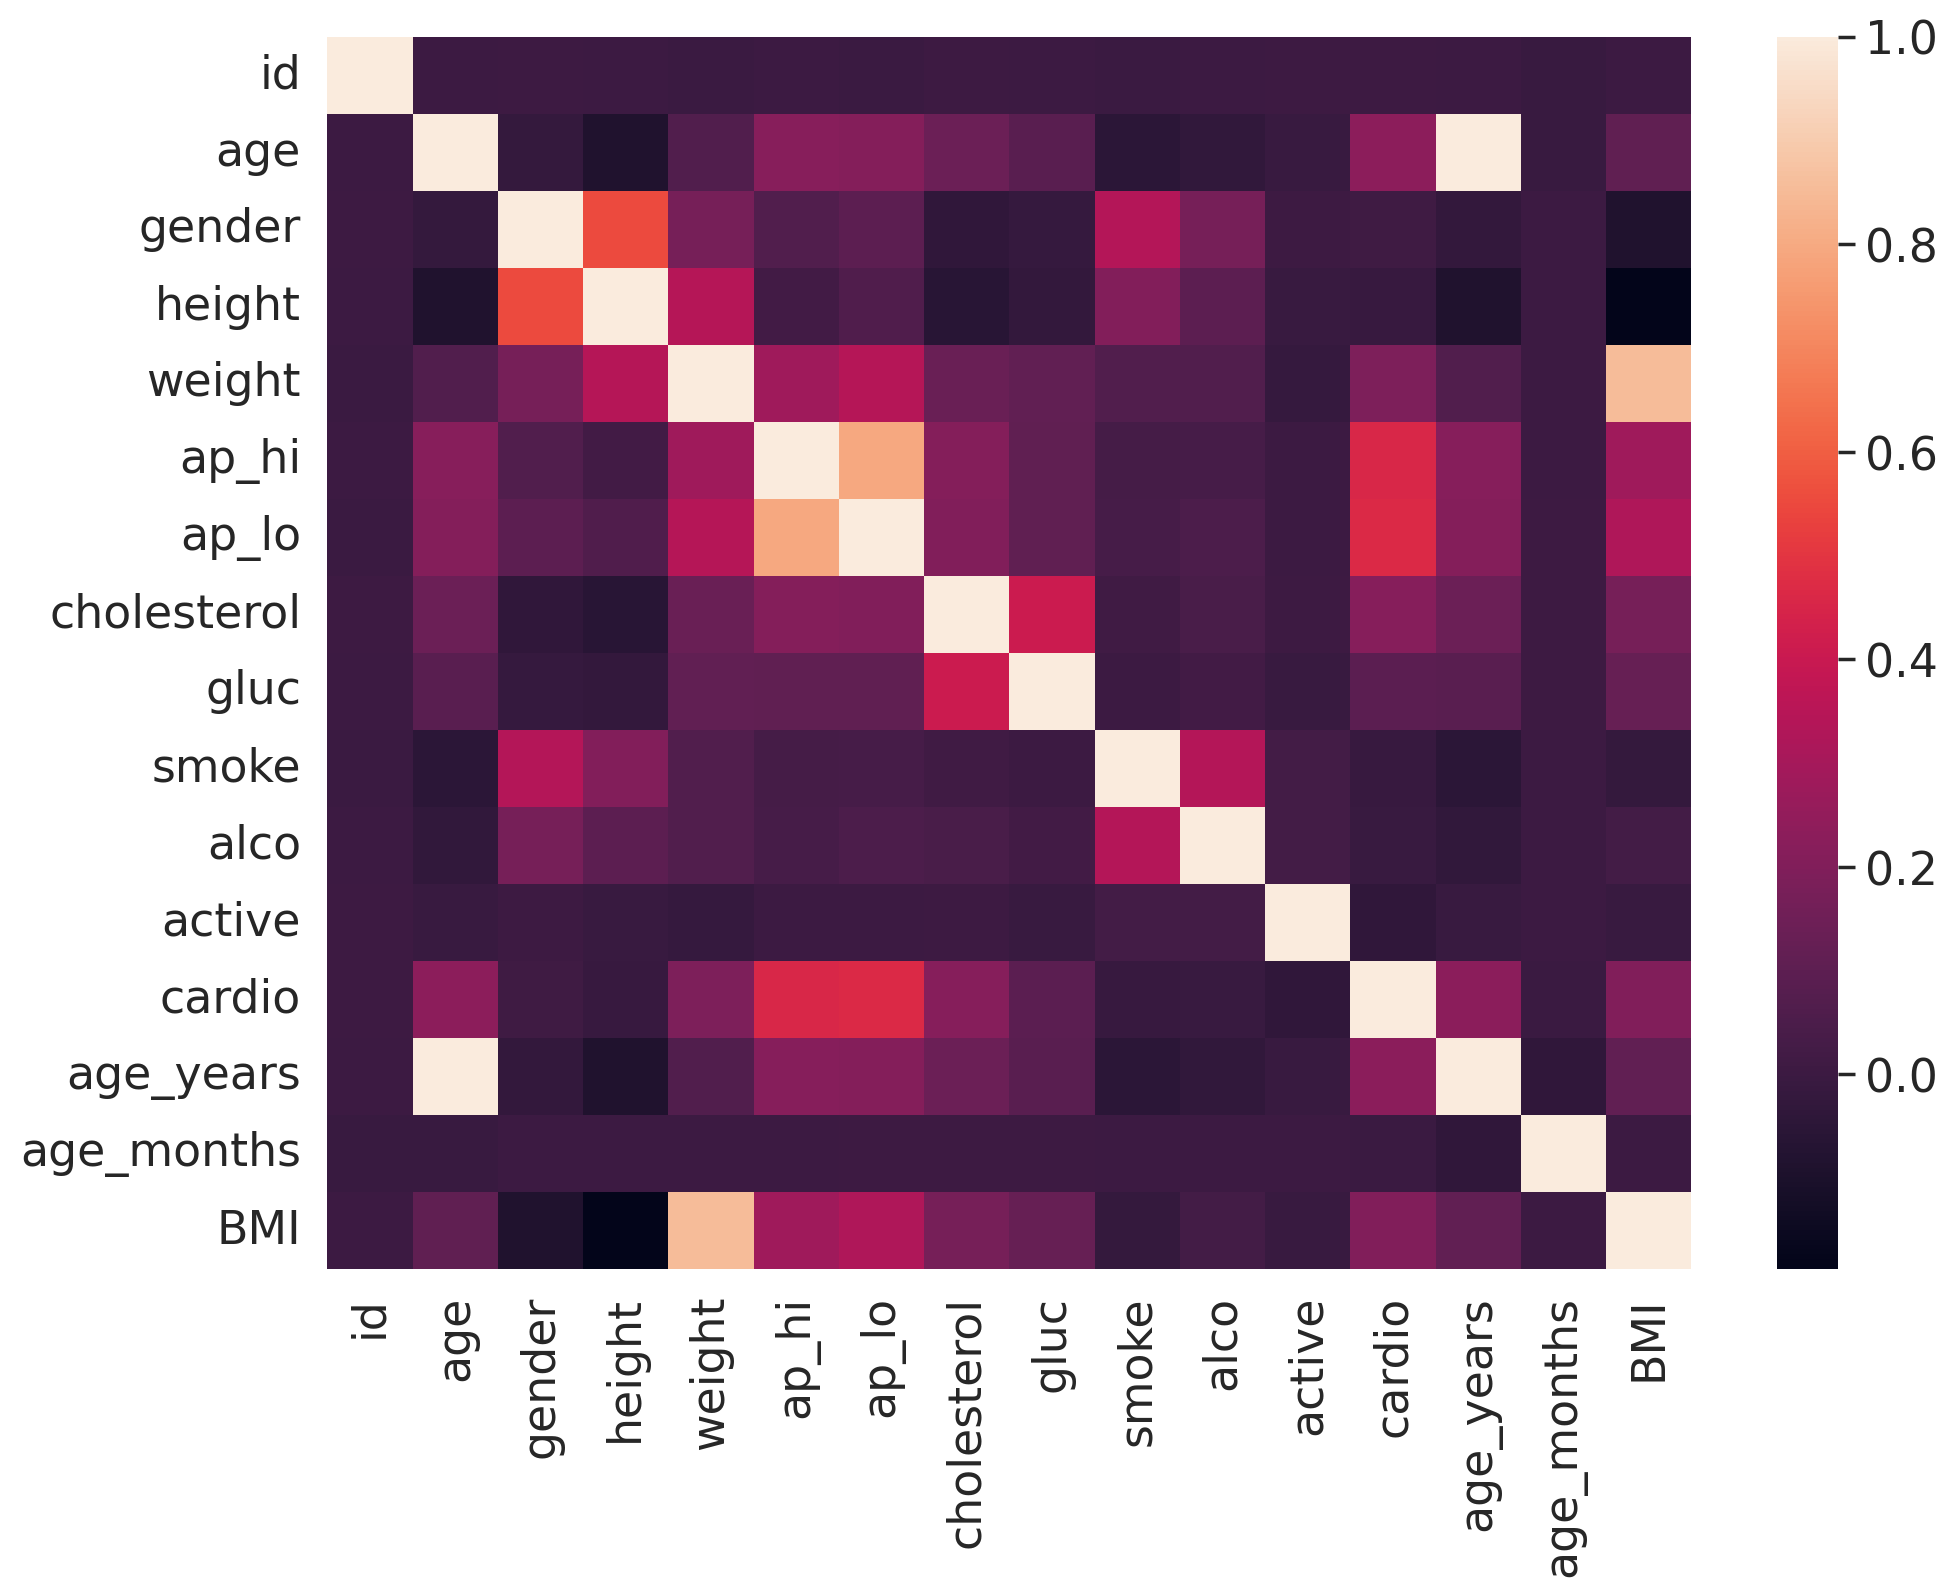

In [105]:
sns.heatmap(df.corr(method="spearman"))

In [128]:
plt.rcParams['figure.figsize'] = (20, 6)

<Axes: xlabel='age_years', ylabel='count'>

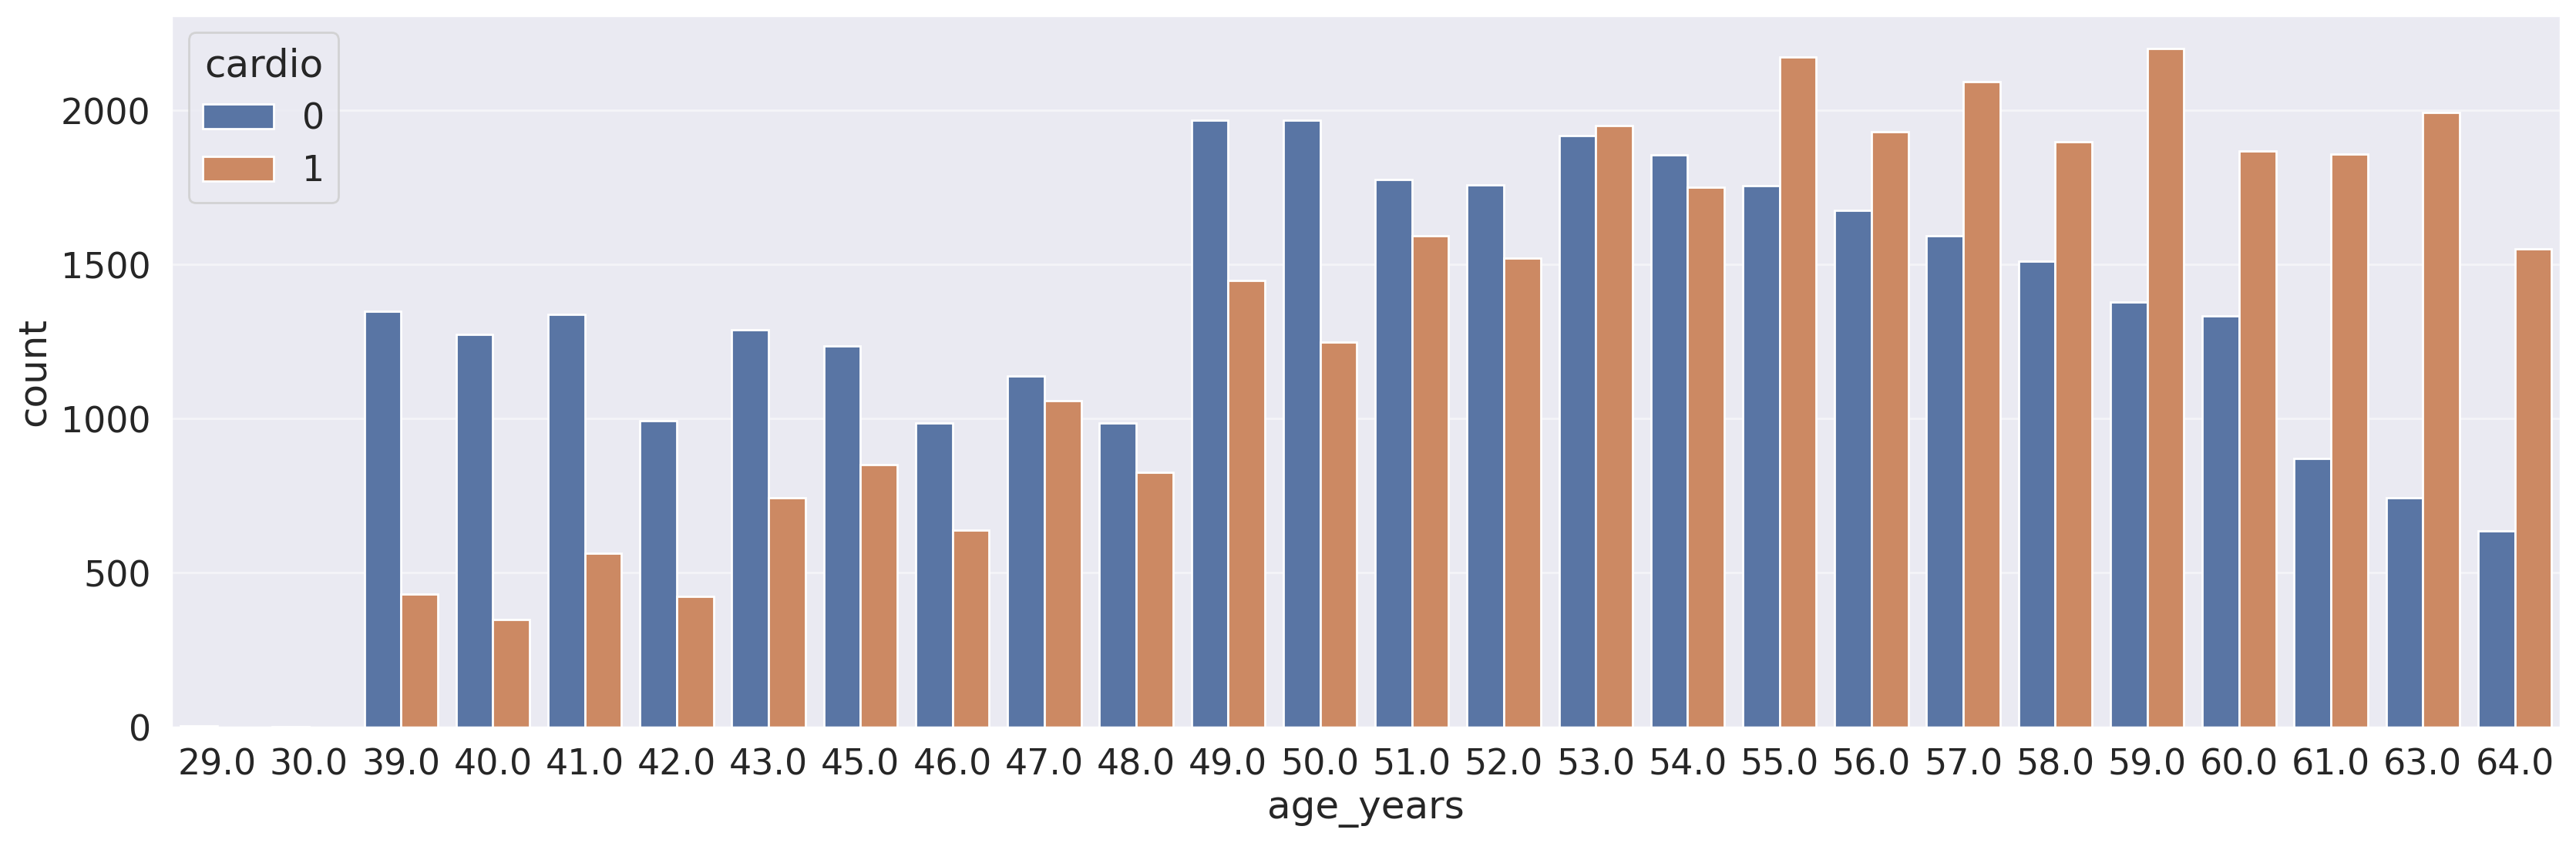

In [131]:
sns.countplot(data=df, x = "age_years",  hue = "cardio")